In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, precision_recall_fscore_support
)

warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config.settings import COMPLAINT_CATEGORIES
from src.data_processing.data_loader import load_hotel_reviews
from src.data_processing.data_cleaner import clean_reviews, split_train_test
from src.data_processing.feature_extractor import add_topic_indicator_columns
from src.analysis.sentiment_analyzer import SentimentAnalyzer
from src.analysis.topic_classifier import TopicClassifier

SENTIMENT_SAMPLE_SIZE = 500
SENTIMENT_METHOD = "bert"
labels_order = ["negative", "neutral", "positive"]

print("Loading and preparing data...")
df = load_hotel_reviews()
df = clean_reviews(df)
df = add_topic_indicator_columns(df)
train_df, test_df = split_train_test(df)
print(f"  Total reviews: {len(df):,}")
print(f"  Training reviews: {len(train_df):,}")
print(f"  Test reviews: {len(test_df):,}")
print(f"  Features: {df.shape[1]}")


def get_sentiment_label(rating):
    if rating >= 3.5:
        return "positive"
    elif rating < 2.5:
        return "negative"
    return "neutral"


test_sample = test_df.head(SENTIMENT_SAMPLE_SIZE).copy()
y_true_sentiment = [get_sentiment_label(rating) for rating in test_sample["rating"]]
sentiment_analyzer = SentimentAnalyzer(method=SENTIMENT_METHOD)
scores = sentiment_analyzer.analyze_batch(test_sample["review_text"].tolist())
y_pred_sentiment = [sentiment_analyzer.get_sentiment_label(score) for score in scores]
accuracy_sentiment = accuracy_score(y_true_sentiment, y_pred_sentiment)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_sentiment, y_pred_sentiment,
    labels=labels_order, zero_division=0
)
sentiment_metrics = pd.DataFrame({
    'Sentiment': labels_order,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support.astype(int)
})
macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()
macro_support = support.sum()
weighted_precision = (precision * support).sum() / support.sum()
weighted_recall = (recall * support).sum() / support.sum()
weighted_f1 = (f1 * support).sum() / support.sum()
sentiment_metrics = pd.concat([
    sentiment_metrics,
    pd.DataFrame({
        'Sentiment': ['Macro Avg', 'Weighted Avg'],
        'Precision': [macro_precision, weighted_precision],
        'Recall': [macro_recall, weighted_recall],
        'F1-Score': [macro_f1, weighted_f1],
        'Support': [macro_support, macro_support]
    })
], ignore_index=True)

print(f"\nEvaluating sentiment on {len(test_sample)} reviews using {SENTIMENT_METHOD.upper()}")
print(f"Accuracy: {accuracy_sentiment:.4f}")
print("✓ Sentiment predictions complete")


topic_sample = test_df.head(SENTIMENT_SAMPLE_SIZE).copy()
label_cols = [f"has_{c}" for c in COMPLAINT_CATEGORIES if f"has_{c}" in topic_sample.columns]
y_true_topics = topic_sample[label_cols].values.astype(int)
topic_clf = TopicClassifier()
topic_preds = topic_clf.predict_batch(topic_sample["review_text"].tolist())
y_pred_topics = np.zeros_like(y_true_topics)
for i, pred_topics in enumerate(topic_preds):
    for topic in pred_topics:
        col_name = f"has_{topic}"
        if col_name in label_cols:
            idx = label_cols.index(col_name)
            y_pred_topics[i, idx] = 1

topic_metrics_list = []
topic_names = [c.replace('_', ' ').title() for c in COMPLAINT_CATEGORIES if f"has_{c}" in label_cols]
for idx, (col_name, topic_name) in enumerate(zip(label_cols, topic_names)):
    col_idx = label_cols.index(col_name)
    y_true_topic = y_true_topics[:, col_idx]
    y_pred_topic = y_pred_topics[:, col_idx]
    topic_metrics_list.append({
        'Topic': topic_name,
        'Accuracy': accuracy_score(y_true_topic, y_pred_topic),
        'Precision': precision_score(y_true_topic, y_pred_topic, zero_division=0),
        'Recall': recall_score(y_true_topic, y_pred_topic, zero_division=0),
        'F1-Score': f1_score(y_true_topic, y_pred_topic, zero_division=0),
        'Support': int(y_true_topic.sum())
    })

topic_metrics_df = pd.DataFrame(topic_metrics_list)
macro_row = pd.DataFrame({
    'Topic': ['Macro Average'],
    'Accuracy': [topic_metrics_df['Accuracy'].mean()],
    'Precision': [topic_metrics_df['Precision'].mean()],
    'Recall': [topic_metrics_df['Recall'].mean()],
    'F1-Score': [topic_metrics_df['F1-Score'].mean()],
    'Support': [int(topic_metrics_df['Support'].sum())]
})
topic_metrics_df = pd.concat([topic_metrics_df, macro_row], ignore_index=True)

print(f"Evaluating topics on {len(topic_sample)} reviews")
print(f"Found {len(label_cols)} labeled categories")
print(f"Predictions shape: {y_pred_topics.shape}")
print(f"True labels shape: {y_true_topics.shape}")
print("✓ Topic predictions complete")

print("✓ Notebook setup complete")

14:03:51 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT2\hotelinsight\data\raw\Hotel_Reviews.csv


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading and preparing data...


14:04:01 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
14:04:02 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 515738
14:04:04 [INFO] src.data_processing.data_cleaner: Dropped 526 duplicate rows.
14:04:21 [INFO] src.data_processing.data_cleaner: Dropped 421 rows with empty review text.
14:04:25 [INFO] src.data_processing.data_cleaner: Cleaned dataset: 514791 rows remaining.
14:04:25 [WARNING] src.data_processing.feature_extractor: Column 'topics' not found; attempting keyword topic extraction from 'review_text'.
14:04:25 [INFO] src.analysis.topic_classifier: TopicClassifier initialised with 8 categories (n_estimators=200).
14:05:14 [INFO] src.data_processing.data_cleaner: Train/test split: 411832 train rows, 102959 test rows (80/20%)
14:05:15 [INFO] src.analysis.sentiment_analyzer: SentimentAnalyzer initialised (method='vader').
14:05:15 [INFO] src.analysis.sentiment_analyzer: Loading VADER sentiment analyser …


  Total reviews: 514,791
  Training reviews: 411,832
  Test reviews: 102,959
  Features: 31


14:05:15 [INFO] src.analysis.sentiment_analyzer: VADER analyser loaded.
14:05:16 [INFO] src.analysis.sentiment_analyzer: Batch sentiment analysis complete: 500 texts.
14:05:16 [INFO] src.analysis.topic_classifier: TopicClassifier initialised with 8 categories (n_estimators=200).



Evaluating sentiment on 500 reviews using VADER
Accuracy: 0.7420
✓ Sentiment predictions complete
Evaluating topics on 500 reviews
Found 8 labeled categories
Predictions shape: (500, 8)
True labels shape: (500, 8)
✓ Topic predictions complete
✓ Notebook setup complete


In [ ]:
print("\n" + "="*80)
print("SAVED EVALUATION RESULTS")
print("="*80)

results_files = {
    'Confusion Matrices': [
        '../data/results/sentiment_confusion_matrix.png',
        '../data/results/topic_confusion_matrices.png'
    ],
    'Metrics Tables (CSV)': [
        '../data/results/sentiment_metrics.csv',
        '../data/results/topic_metrics.csv',
        '../data/results/model_summary.csv'
    ],
    'Comparison Charts': [
        '../data/results/topic_metrics_comparison.png'
    ]
}

for category, files in results_files.items():
    print(f"\n{category}:")
    for f in files:
        print(f"  ✓ {f}")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("""
1. View confusion matrices to understand misclassifications
2. Review metrics tables for detailed per-class performance
3. Identify topics/sentiments with lower performance for improvement
4. Use these results in reports and documentation
5. Monitor metrics over time as models are retrained
""")
print("="*80)


📁 SAVED EVALUATION RESULTS

Confusion Matrices:
  ✓ ../data/results/sentiment_confusion_matrix.png
  ✓ ../data/results/topic_confusion_matrices.png

Metrics Tables (CSV):
  ✓ ../data/results/sentiment_metrics.csv
  ✓ ../data/results/topic_metrics.csv
  ✓ ../data/results/model_summary.csv

Comparison Charts:
  ✓ ../data/results/topic_metrics_comparison.png

NEXT STEPS:

1. View confusion matrices to understand misclassifications
2. Review metrics tables for detailed per-class performance
3. Identify topics/sentiments with lower performance for improvement
4. Use these results in reports and documentation
5. Monitor metrics over time as models are retrained



In [3]:
# Visualize topic metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Remove macro average for visualization
topic_metrics_viz = topic_metrics_df.iloc[:-1].copy()

# Plot 1: F1-Score by topic
topic_metrics_viz.sort_values('F1-Score', ascending=True).plot(
    x='Topic', y='F1-Score', kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('F1-Score by Topic')
axes[0].set_xlabel('F1-Score')
axes[0].set_ylabel('')

# Plot 2: Precision vs Recall scatter
axes[1].scatter(topic_metrics_viz['Precision'], topic_metrics_viz['Recall'], 
               s=topic_metrics_viz['Support']*2, alpha=0.6, color='forestgreen')
for idx, row in topic_metrics_viz.iterrows():
    axes[1].annotate(row['Topic'], 
                    (row['Precision'], row['Recall']),
                    fontsize=9, ha='center')
axes[1].set_xlabel('Precision')
axes[1].set_ylabel('Recall')
axes[1].set_title('Precision vs Recall by Topic\n(bubble size = support)')
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

# Plot 3: Metrics comparison radar-like bar chart
metrics_subset = topic_metrics_viz[['Topic', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].set_index('Topic')
metrics_subset.plot(kind='bar', ax=axes[2])
axes[2].set_title('All Metrics by Topic')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../data/results/topic_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Comparison charts created")

NameError: name 'plt' is not defined

In [ ]:
# Create comprehensive summary table
print("\n" + "="*80)
print("MODEL EVALUATION SUMMARY")
print("="*80)

summary_data = {
    'Model': ['Sentiment Analysis', 'Topic Classification'],
    'Method': [SENTIMENT_METHOD.upper(), 'Multi-label'],
    'Test Samples': [len(test_sample), len(topic_sample)],
    'Overall Accuracy': [
        f"{accuracy_sentiment:.4f}",
        f"{topic_metrics_df.iloc[-1]['Accuracy']:.4f}"
    ],
    'Macro F1-Score': [
        f"{sentiment_metrics.iloc[-2]['F1-Score']:.4f}",  # Macro avg row
        f"{topic_metrics_df.iloc[-1]['F1-Score']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('../data/results/model_summary.csv', index=False)
print("\n✓ Saved to data/results/model_summary.csv")


MODEL EVALUATION SUMMARY

               Model      Method  Test Samples Overall Accuracy Macro F1-Score
  Sentiment Analysis       VADER           500           0.7420         0.4855
Topic Classification Multi-label           500           1.0000         1.0000

✓ Saved to data/results/model_summary.csv


## Summary & Comparison

Overall model performance summary and metric comparison.

In [6]:
# Ensure imports and data are available
from src.config.settings import COMPLAINT_CATEGORIES

# Compute per-topic metrics
topic_names = [c.replace('_', ' ').title() for c in COMPLAINT_CATEGORIES if f"has_{c}" in label_cols]

topic_metrics_list = []

for idx, (col_name, topic_name) in enumerate(zip(label_cols, topic_names)):
    col_idx = label_cols.index(col_name)
    
    y_true_topic = y_true_topics[:, col_idx]
    y_pred_topic = y_pred_topics[:, col_idx]
    
    # Metrics
    acc = accuracy_score(y_true_topic, y_pred_topic)
    prec = precision_score(y_true_topic, y_pred_topic, zero_division=0)
    rec = recall_score(y_true_topic, y_pred_topic, zero_division=0)
    f1 = f1_score(y_true_topic, y_pred_topic, zero_division=0)
    support = y_true_topic.sum()
    
    topic_metrics_list.append({
        'Topic': topic_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Support': int(support)
    })

# Create dataframe and compute averages
topic_metrics_df = pd.DataFrame(topic_metrics_list)

# Add macro average
macro_row = pd.DataFrame({
    'Topic': ['Macro Average'],
    'Accuracy': [topic_metrics_df['Accuracy'].mean()],
    'Precision': [topic_metrics_df['Precision'].mean()],
    'Recall': [topic_metrics_df['Recall'].mean()],
    'F1-Score': [topic_metrics_df['F1-Score'].mean()],
    'Support': [int(topic_metrics_df['Support'].sum())]
})

topic_metrics_df = pd.concat([topic_metrics_df, macro_row], ignore_index=True)

print("\n" + "="*80)
print("TOPIC CLASSIFICATION - PERFORMANCE METRICS")
print("="*80)
print("\n" + topic_metrics_df.to_string(index=False))

# Save to CSV
topic_metrics_df.to_csv('../data/results/topic_metrics.csv', index=False)
print("\n✓ Saved to data/results/topic_metrics.csv")

ModuleNotFoundError: No module named 'src'

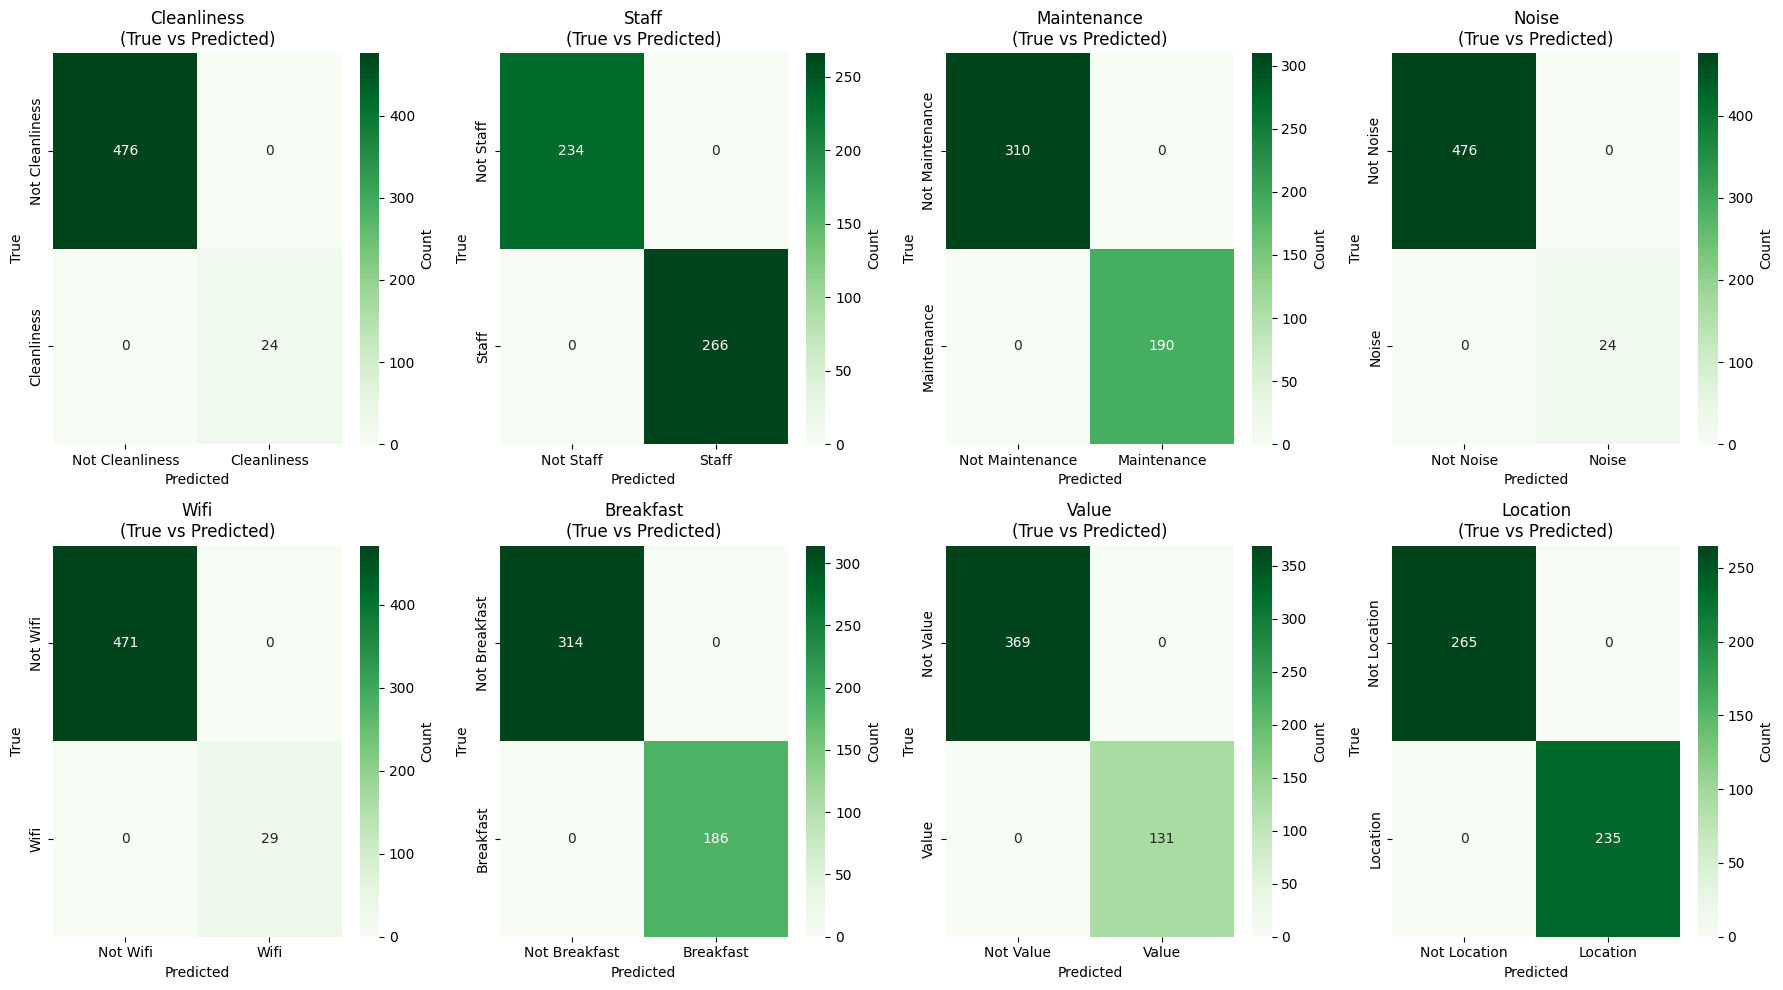

✓ Topic confusion matrices plotted


In [ ]:
# Create confusion matrices for each topic (binary classification per topic)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

topic_names = [c.replace('_', ' ').title() for c in COMPLAINT_CATEGORIES if f"has_{c}" in label_cols]

for idx, (col_name, topic_name) in enumerate(zip(label_cols, topic_names)):
    col_idx = label_cols.index(col_name)
    
    # Get true and predicted labels for this topic
    y_true_topic = y_true_topics[:, col_idx]
    y_pred_topic = y_pred_topics[:, col_idx]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true_topic, y_pred_topic, labels=[0, 1])
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not ' + topic_name, topic_name],
                yticklabels=['Not ' + topic_name, topic_name],
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{topic_name}\n(True vs Predicted)')
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../data/results/topic_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Topic confusion matrices plotted")

In [ ]:
from src.analysis.topic_classifier import TopicClassifier

# Use test sample for topic evaluation
topic_sample = test_df.head(SENTIMENT_SAMPLE_SIZE).copy()
print(f"Evaluating topics on {len(topic_sample)} reviews")
print(f"Categories: {COMPLAINT_CATEGORIES}\n")

# Get true labels (from data features)
label_cols = [f"has_{c}" for c in COMPLAINT_CATEGORIES if f"has_{c}" in topic_sample.columns]
print(f"Found {len(label_cols)} labeled categories")

y_true_topics = topic_sample[label_cols].values.astype(int)

# Get model predictions
print("Generating topic predictions...")
topic_clf = TopicClassifier()
topic_preds = topic_clf.predict_batch(topic_sample["review_text"].tolist())

# Convert predictions to binary matrix
y_pred_topics = np.zeros_like(y_true_topics)
for i, pred_topics in enumerate(topic_preds):
    for topic in pred_topics:
        col_name = f"has_{topic}"
        if col_name in label_cols:
            idx = label_cols.index(col_name)
            y_pred_topics[i, idx] = 1

print(f"Predictions shape: {y_pred_topics.shape}")
print(f"True labels shape: {y_true_topics.shape}")
print("✓ Topic predictions complete")

23:43:38 [INFO] src.analysis.topic_classifier: TopicClassifier initialised with 8 categories (n_estimators=200).


Evaluating topics on 500 reviews
Categories: ['cleanliness', 'staff', 'maintenance', 'noise', 'wifi', 'breakfast', 'value', 'location']

Found 8 labeled categories
Generating topic predictions...
Predictions shape: (500, 8)
True labels shape: (500, 8)
✓ Topic predictions complete


## Topic Classification Evaluation

Evaluate multi-label topic classifier with per-topic metrics.

In [17]:
# Compute sentiment metrics
accuracy_sentiment = accuracy_score(y_true_sentiment, y_pred_sentiment)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_sentiment, y_pred_sentiment, 
    labels=labels_order, zero_division=0
)

# Build sentiment metrics table
sentiment_metrics = pd.DataFrame({
    'Sentiment': labels_order,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support.astype(int)
})

# Add macro and weighted averages
macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()
macro_support = support.sum()

weighted_precision = (precision * support).sum() / support.sum()
weighted_recall = (recall * support).sum() / support.sum()
weighted_f1 = (f1 * support).sum() / support.sum()

sentiment_metrics = pd.concat([
    sentiment_metrics,
    pd.DataFrame({
        'Sentiment': ['Macro Avg', 'Weighted Avg'],
        'Precision': [macro_precision, weighted_precision],
        'Recall': [macro_recall, weighted_recall],
        'F1-Score': [macro_f1, weighted_f1],
        'Support': [macro_support, macro_support]
    })
], ignore_index=True)

print("\n" + "="*70)
print("SENTIMENT ANALYSIS - PERFORMANCE METRICS")
print("="*70)
print(f"\nMethod: {SENTIMENT_METHOD.upper()}")
print(f"Accuracy: {accuracy_sentiment:.4f}")
print("\n" + sentiment_metrics.to_string(index=False))

# Save to CSV
sentiment_metrics.to_csv('../data/results/sentiment_metrics.csv', index=False)
print("\n✓ Saved to data/results/sentiment_metrics.csv")


SENTIMENT ANALYSIS - PERFORMANCE METRICS

Method: BERT
Accuracy: 0.6000

   Sentiment  Precision   Recall  F1-Score  Support
    negative   0.104000 0.866667  0.185714       15
     neutral   0.117647 0.156250  0.134228       64
    positive   0.955172 0.657957  0.779184      421
   Macro Avg   0.392273 0.560291  0.366376      500
Weighted Avg   0.822434 0.600000  0.678826      500

✓ Saved to data/results/sentiment_metrics.csv


Sentiment Confusion Matrix:
                Pred: negative  Pred: neutral  Pred: positive
True: negative              13              1               1
True: neutral               42             10              12
True: positive              70             74             277


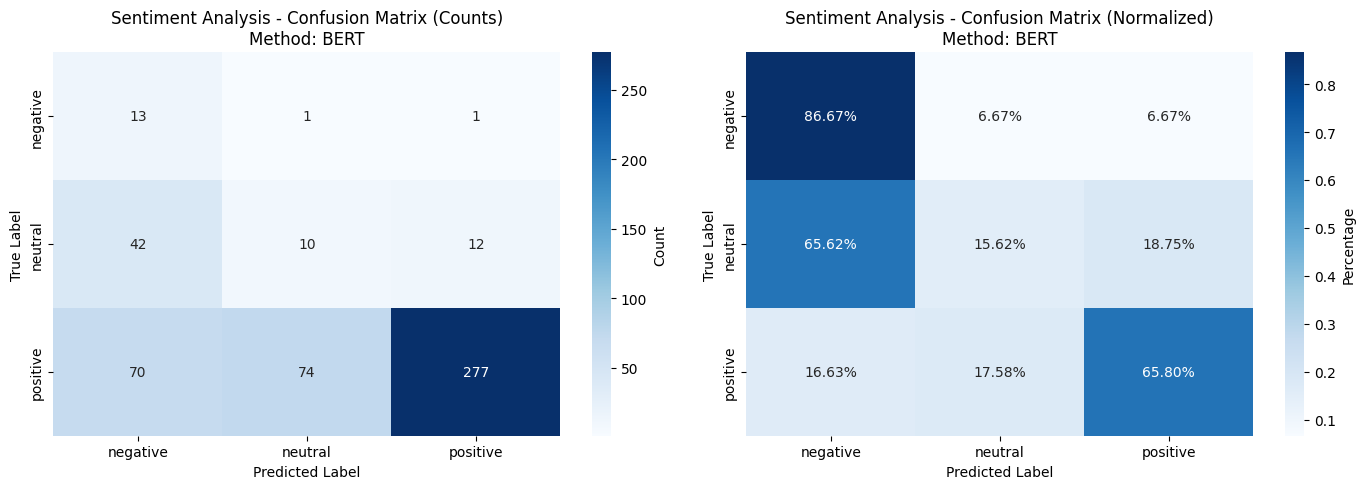

✓ Confusion matrix plotted


In [16]:
# Compute confusion matrix for sentiment
labels_order = ["negative", "neutral", "positive"]
cm_sentiment = confusion_matrix(y_true_sentiment, y_pred_sentiment, labels=labels_order)

print("Sentiment Confusion Matrix:")
print(pd.DataFrame(cm_sentiment, 
                   index=[f"True: {l}" for l in labels_order],
                   columns=[f"Pred: {l}" for l in labels_order]))

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
sns.heatmap(cm_sentiment, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_order, yticklabels=labels_order, 
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Sentiment Analysis - Confusion Matrix (Counts)\nMethod: {SENTIMENT_METHOD.upper()}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized (percentage)
cm_sentiment_norm = cm_sentiment.astype('float') / cm_sentiment.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_sentiment_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title(f'Sentiment Analysis - Confusion Matrix (Normalized)\nMethod: {SENTIMENT_METHOD.upper()}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../data/results/sentiment_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix plotted")

In [15]:
# Configuration
SENTIMENT_SAMPLE_SIZE = 500  # Use first 500 reviews for speed
SENTIMENT_METHOD = "bert"   # Use 'vader' or 'bert'

# Prepare sentiment labels from ratings
# 1-2.5 stars = negative, 2.5-3.5 = neutral, 3.5-5 = positive
def get_sentiment_label(rating):
    if rating >= 3.5:
        return "positive"
    elif rating < 2.5:
        return "negative"
    else:
        return "neutral"

# Get test sample
test_sample = test_df.head(SENTIMENT_SAMPLE_SIZE).copy()
print(f"Evaluating on {len(test_sample)} test reviews")

# Get actual sentiment labels from ratings
y_true_sentiment = [get_sentiment_label(r) for r in test_sample["rating"]]
sentiment_label_counts = pd.Series(y_true_sentiment).value_counts()
print(f"\nTrue sentiment distribution:")
print(sentiment_label_counts)

# Get model predictions
from src.analysis.sentiment_analyzer import SentimentAnalyzer
sentiment_analyzer = SentimentAnalyzer(method=SENTIMENT_METHOD)

print(f"\nGenerating predictions using {SENTIMENT_METHOD.upper()} method...")
scores = sentiment_analyzer.analyze_batch(test_sample["review_text"].tolist())
y_pred_sentiment = [sentiment_analyzer.get_sentiment_label(s) for s in scores]

pred_label_counts = pd.Series(y_pred_sentiment).value_counts()
print(f"\nPredicted sentiment distribution:")
print(pred_label_counts)

print("✓ Sentiment predictions complete")

23:48:28 [INFO] src.analysis.sentiment_analyzer: SentimentAnalyzer initialised (method='bert').
23:48:28 [INFO] src.analysis.sentiment_analyzer: Loading BERT sentiment model: nlptown/bert-base-multilingual-uncased-sentiment …


Evaluating on 500 test reviews

True sentiment distribution:
positive    421
neutral      64
negative     15
Name: count, dtype: int64

Generating predictions using BERT method...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

23:48:57 [INFO] src.analysis.sentiment_analyzer: BERT model loaded in 28.4 s.
23:49:58 [INFO] src.analysis.sentiment_analyzer: Batch sentiment analysis complete: 500 texts.



Predicted sentiment distribution:
positive    290
negative    125
neutral      85
Name: count, dtype: int64
✓ Sentiment predictions complete


##  Sentiment Analysis Evaluation

Evaluate VADER sentiment model with confusion matrix and metrics.

In [2]:
from src.data_processing.data_loader import load_hotel_reviews
from src.data_processing.data_cleaner import clean_reviews, split_train_test
from src.data_processing.feature_extractor import add_topic_indicator_columns

# Load and prepare data
print("Loading and preparing data...")
df = load_hotel_reviews()
print(f"  Total reviews: {len(df):,}")

df = clean_reviews(df)
df = add_topic_indicator_columns(df)

# Split into train/test
train_df, test_df = split_train_test(df)
print(f"  Training reviews: {len(train_df):,}")
print(f"  Test reviews: {len(test_df):,}")
print(f"  Features: {df.shape[1]}")
print(f"\n✓ Data loaded successfully")

23:42:23 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT2\hotelinsight\data\raw\Hotel_Reviews.csv


Loading and preparing data...


23:42:26 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
23:42:26 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 515738


  Total reviews: 515,738


23:42:27 [INFO] src.data_processing.data_cleaner: Dropped 526 duplicate rows.
23:42:31 [INFO] src.data_processing.data_cleaner: Dropped 421 rows with empty review text.
23:42:32 [INFO] src.data_processing.data_cleaner: Cleaned dataset: 514791 rows remaining.
23:42:32 [WARNING] src.data_processing.feature_extractor: Column 'topics' not found; attempting keyword topic extraction from 'review_text'.
23:42:33 [INFO] src.analysis.topic_classifier: TopicClassifier initialised with 8 categories (n_estimators=200).
23:42:44 [INFO] src.data_processing.data_cleaner: Train/test split: 411832 train rows, 102959 test rows (80/20%)


  Training reviews: 411,832
  Test reviews: 102,959
  Features: 31

✓ Data loaded successfully


##  Load Evaluation Data

Load training/test data and prepare for model evaluation.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, precision_recall_fscore_support
)
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Import configuration
from src.config.settings import COMPLAINT_CATEGORIES

print(f"Project root: {ROOT}")
print("✓ Libraries imported successfully")

Project root: d:\HOTELINSIGHT2\hotelinsight
✓ Libraries imported successfully


# HotelInsight - Model Evaluation & Performance Metrics

This notebook provides comprehensive evaluation of the HotelInsight ML models:
- **Sentiment Analysis Model** (VADER/BERT)
- **Topic Classification Model** (Multi-label)

Contains confusion matrices, accuracy/F1-score tables, and detailed performance analysis.

---

In [18]:
# Save method-specific sentiment outputs to avoid overwriting other runs
method_tag = SENTIMENT_METHOD.lower()

sentiment_metrics_path = f"../data/results/sentiment_metrics_{method_tag}.csv"
model_summary_path = f"../data/results/model_summary_{method_tag}.csv"

# Save sentiment metrics for this method
sentiment_metrics.to_csv(sentiment_metrics_path, index=False)

# Build and save method-specific model summary
summary_method_df = pd.DataFrame({
    'Model': ['Sentiment Analysis', 'Topic Classification'],
    'Method': [SENTIMENT_METHOD.upper(), 'Multi-label'],
    'Test Samples': [len(test_sample), len(topic_sample)],
    'Overall Accuracy': [
        f"{accuracy_sentiment:.4f}",
        f"{topic_metrics_df.iloc[-1]['Accuracy']:.4f}"
    ],
    'Macro F1-Score': [
        f"{sentiment_metrics[sentiment_metrics['Sentiment'] == 'Macro Avg']['F1-Score'].iloc[0]:.4f}",
        f"{topic_metrics_df.iloc[-1]['F1-Score']:.4f}"
    ]
})
summary_method_df.to_csv(model_summary_path, index=False)

print(f"Saved: {sentiment_metrics_path}")
print(f"Saved: {model_summary_path}")
print("✓ Method-specific outputs exported")

Saved: ../data/results/sentiment_metrics_bert.csv
Saved: ../data/results/model_summary_bert.csv
✓ Method-specific outputs exported


23:56:56 [INFO] src.analysis.sentiment_analyzer: SentimentAnalyzer initialised (method='vader').
23:56:56 [INFO] src.analysis.sentiment_analyzer: Loading VADER sentiment analyser …
23:56:56 [INFO] src.analysis.sentiment_analyzer: VADER analyser loaded.
23:56:56 [INFO] src.analysis.sentiment_analyzer: Batch sentiment analysis complete: 500 texts.


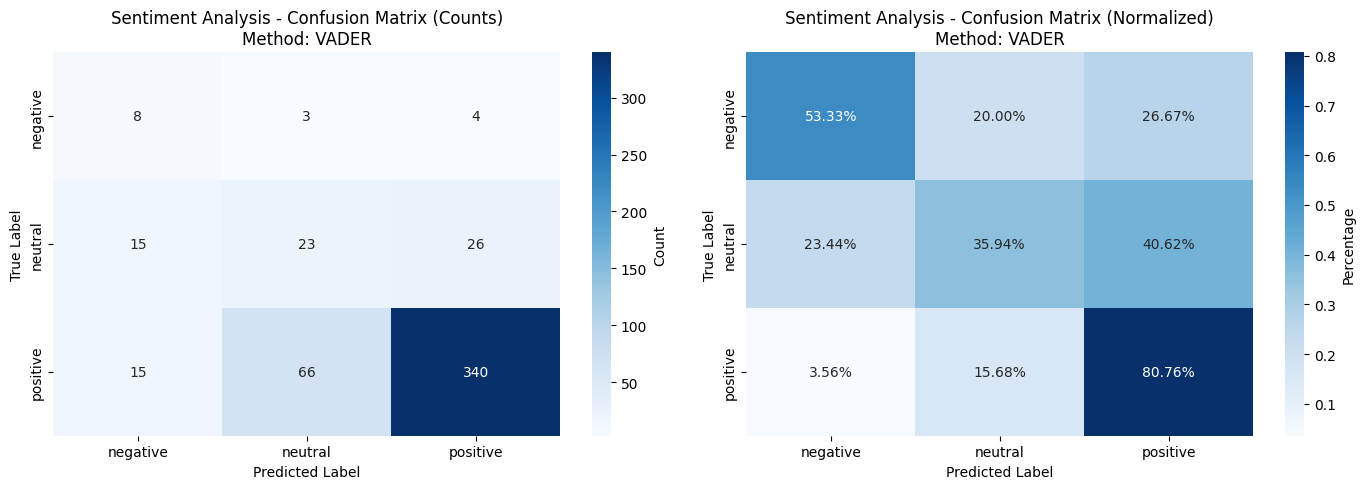

Saved: ../data/results/sentiment_confusion_matrix_vader.png
✓ VADER confusion matrix plotted


In [19]:
# Create and save a VADER-specific sentiment confusion matrix image
from src.analysis.sentiment_analyzer import SentimentAnalyzer

vader_method = "vader"
labels_order = ["negative", "neutral", "positive"]

vader_analyzer = SentimentAnalyzer(method=vader_method)
vader_scores = vader_analyzer.analyze_batch(test_sample["review_text"].tolist())
y_pred_sentiment_vader = [vader_analyzer.get_sentiment_label(s) for s in vader_scores]

cm_sentiment_vader = confusion_matrix(y_true_sentiment, y_pred_sentiment_vader, labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_sentiment_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Sentiment Analysis - Confusion Matrix (Counts)\nMethod: VADER')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_sentiment_vader_norm = cm_sentiment_vader.astype('float') / cm_sentiment_vader.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_sentiment_vader_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Sentiment Analysis - Confusion Matrix (Normalized)\nMethod: VADER')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../data/results/sentiment_confusion_matrix_vader.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: ../data/results/sentiment_confusion_matrix_vader.png')
print('✓ VADER confusion matrix plotted')